## Transformer for multivariate time-series forecasting  

Two token-embedding schemes:

  mode="step"  -> one token per time step (token_dim = d)
  mode="patch" -> one token per group of `patch_len` consecutive steps,
                  i.e. the "n-lagged" tokenization (token_dim = d * patch_len)

The patch/lag scheme is the same idea behind PatchTST (Nie et al., ICLR 2023,
"A Time Series is Worth 64 Words", arXiv:2211.14730): grouping n consecutive
steps into one token shortens the attention sequence length by a factor of n
and lets local (within-token) dynamics be handled by the linear projection
rather than by attention itself.


In [ ]:
import numpy as np
import torch
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

import math

import torch.nn as nn


In [ ]:




class TokenEmbedding(nn.Module):
    """(B, T, d) -> (B, N, d_model) token sequence."""

    def __init__(self, d_features, d_model, mode="step", patch_len=1, stride=None):
        super().__init__()
        assert mode in ("step", "patch")
        self.mode = mode
        self.patch_len = patch_len
        self.stride = stride or patch_len  # non-overlapping patches by default
        in_dim = d_features if mode == "step" else d_features * patch_len
        self.proj = nn.Linear(in_dim, d_model)

    def forward(self, x):
        # x: (B, T, d)
        if self.mode == "step":
            tokens = x  # (B, T, d) -- one token per time step
        else:
            B, T, d = x.shape
            p, s = self.patch_len, self.stride
            n_tokens = (T - p) // s + 1
            patches = torch.stack(
                [x[:, k * s: k * s + p, :] for k in range(n_tokens)], dim=1
            )  # (B, n_tokens, p, d)
            tokens = patches.reshape(B, n_tokens, p * d)  # flatten each patch's p*d values
        return self.proj(tokens)  # (B, N, d_model)


class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]


class TSForecastTransformer(nn.Module):
    """
    Encoder-only Transformer for direct multi-step forecasting:
    input (B, T, d) -> output (B, H, d)
    """

    def __init__(self, d_features, H, d_model=64, nhead=4, num_layers=2,
                 dim_feedforward=128, dropout=0.1,
                 mode="step", patch_len=1, stride=None):
        super().__init__()
        self.H, self.d_features = H, d_features
        self.tokenizer = TokenEmbedding(d_features, d_model, mode, patch_len, stride)
        self.pos_enc = PositionalEncoding(d_model)
        layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_feedforward,
            dropout=dropout, batch_first=True,
        )
        self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers)
        self.out_proj = nn.Linear(d_model, H * d_features)

    def forward(self, x):
        # x: (B, T, d)
        tok = self.pos_enc(self.tokenizer(x))     # (B, N, d_model)
        enc = self.encoder(tok)                    # (B, N, d_model)
        summary = enc[:, -1, :]                     # last token as summary; 
        # summary = enc.mean(dim=1)                   #  enc.mean(dim=1) to pool instead
        out = self.out_proj(summary)                 # (B, H*d_features)
        return out.view(-1, self.H, self.d_features)




## Time series generation

In [ ]:

# ---------------------------------------------------------------
# 1. Realistic synthetic series: flow, speed, temperature at
#    5-minute resolution, with daily double rush-hour peaks,
#    a weekday/weekend effect, AR(1) noise, and flow-speed coupling.
# ---------------------------------------------------------------
def make_synthetic_traffic(n_days=60, freq_per_day=288, seed=0):
    rng = np.random.default_rng(seed)
    T = n_days * freq_per_day
    t = np.arange(T)
    minute_of_day = t % freq_per_day
    day = t // freq_per_day
    tod = minute_of_day / freq_per_day       # fraction of day, 0..1
    dow = day % 7                            # day of week

    morning = np.exp(-0.5 * ((tod - 0.33) / 0.035) ** 2)   # ~8am peak
    evening = np.exp(-0.5 * ((tod - 0.75) / 0.05) ** 2)    # ~6pm peak
    weekday_factor = np.where(dow < 5, 1.0, 0.5)            # lighter weekends
    base_flow = 200 * weekday_factor * (0.3 + morning + 0.9 * evening) + 30

    flow_noise = np.zeros(T)                                 # AR(1) noise
    for i in range(1, T):
        flow_noise[i] = 0.6 * flow_noise[i - 1] + rng.normal(0, 8)
    flow = np.clip(base_flow + flow_noise, 0, None)

    free_flow_speed = 60
    congestion = (flow - flow.min()) / (flow.max() - flow.min() + 1e-6)
    speed = free_flow_speed * (1 - 0.55 * congestion) + rng.normal(0, 1.5, T)

    temp = (15 + 6 * np.sin(2 * np.pi * (tod - 0.3))
            + 3 * np.sin(2 * np.pi * day / 365) + rng.normal(0, 0.5, T))
    feature_names = ["flow", "speed", "temp"]

    return np.stack([flow, speed, temp], axis=-1).astype(np.float32), feature_names  # (T, 3)

"""
Realistic synthetic multivariate 'smart city' time series generator.

Same (n_days, freq_per_day, seed) signature and (T, d) float32 output
convention as the earlier make_synthetic_traffic(), but with 13 mutually
coupled variables instead of 3 -- a drop-in replacement wherever that
function was used (e.g. in ts_transformer_example.py, just swap the
import and bump d_features from 3 to 13).
"""

import numpy as np


def make_synthetic_smart_city(n_days=60, freq_per_day=288, seed=0):
    """
    5-minute-resolution series with daily/weekly structure and
    cross-variable coupling (weather drives traffic, traffic drives
    pollution/noise/parking, rain shifts mode choice, etc.).

    Columns (axis=-1), 13 total:
      0  flow          vehicles / 5min
      1  speed         km/h
      2  temp          deg C
      3  humidity      %
      4  wind_speed    km/h
      5  precip        mm / 5min
      6  occupancy     % (lane occupancy)
      7  pm25          ug/m3 (air quality)
      8  noise_level   dB
      9  pedestrians   people / 5min
      10 bikes         bikes / 5min
      11 parking_occ   % (parking occupancy, slow/lagged vs. flow)
      12 pt_ridership  passengers / 5min

    Returns
    -------
    X : np.ndarray, shape (n_days * freq_per_day, 13), dtype float32
    """
    rng = np.random.default_rng(seed)
    T = n_days * freq_per_day
    t = np.arange(T)
    minute_of_day = t % freq_per_day
    day = t // freq_per_day
    tod = minute_of_day / freq_per_day       # fraction of day, 0..1
    dow = day % 7                            # day of week
    is_weekday = dow < 5
    weekday_factor = np.where(is_weekday, 1.0, 0.5)

    # ---------------- weather (drives everything downstream) ----------------
    temp = (15 + 6 * np.sin(2 * np.pi * (tod - 0.3))
            + 3 * np.sin(2 * np.pi * day / 365) + rng.normal(0, 0.5, T))

    humidity = np.clip(
        70 - 15 * np.sin(2 * np.pi * (tod - 0.3)) - 0.8 * (temp - temp.mean())
        + rng.normal(0, 3, T), 15, 100)

    wind_speed = np.zeros(T)
    wind_speed[0] = 10.0
    for i in range(1, T):
        wind_speed[i] = 0.9 * wind_speed[i - 1] + 0.1 * 10 + rng.normal(0, 1.0)
    wind_speed = np.clip(wind_speed, 0, None)

    rainy_day = rng.random(n_days) < 0.28
    rain_today = np.repeat(rainy_day, freq_per_day)
    rain_window = np.exp(-0.5 * ((tod - 0.4) / 0.15) ** 2)  # broad midday-ish band
    precip = np.clip(
        rain_today * rain_window * rng.gamma(2.0, 1.2, T) + rng.normal(0, 0.05, T),
        0, None)
    rain_intensity = precip / (precip.max() + 1e-6)  # 0..1, used as a modifier

    # ---------------- traffic core (flow / speed / occupancy) ----------------
    morning = np.exp(-0.5 * ((tod - 0.33) / 0.035) ** 2)   # ~8am peak
    evening = np.exp(-0.5 * ((tod - 0.75) / 0.05) ** 2)    # ~6pm peak
    base_flow = 200 * weekday_factor * (0.3 + morning + 0.9 * evening) + 30
    base_flow *= (1 + 0.10 * rain_intensity)  # mode-shift: more cars when raining

    flow_noise = np.zeros(T)
    for i in range(1, T):
        flow_noise[i] = 0.6 * flow_noise[i - 1] + rng.normal(0, 8)
    flow = np.clip(base_flow + flow_noise, 0, None)

    congestion = (flow - flow.min()) / (flow.max() - flow.min() + 1e-6)
    free_flow_speed = 60
    speed = (free_flow_speed * (1 - 0.55 * congestion)
             - 4 * rain_intensity - 0.05 * wind_speed
             + rng.normal(0, 1.5, T))
    speed = np.clip(speed, 5, None)

    occupancy = np.clip(100 * congestion * 0.7 + rng.normal(0, 4, T), 0, 100)

    # ---------------- environment coupled to traffic ----------------
    pm25 = np.clip(
        15 + 0.12 * flow - 0.8 * wind_speed + rng.normal(0, 3, T), 3, None)

    noise_level = np.clip(
        45 + 10 * np.log1p(flow / 20) + rng.normal(0, 1.5, T), 35, 95)

    # ---------------- active mobility (reduced by rain & cold) ----------------
    ped_shape = (0.5 * np.exp(-0.5 * ((tod - 0.5) / 0.08) ** 2)      # lunchtime
                 + 0.8 * np.exp(-0.5 * ((tod - 0.72) / 0.06) ** 2) + 0.15)  # evening
    weekend_ped_boost = np.where(is_weekday, 1.0, 1.3)
    comfort = np.clip(1 - rain_intensity - 0.02 * np.clip(5 - temp, 0, None), 0.1, 1.3)
    pedestrians = np.clip(
        90 * ped_shape * weekend_ped_boost * comfort + rng.normal(0, 5, T), 0, None)

    bike_shape = 0.5 * morning + 0.4 * evening + 0.05  # commute-like
    bike_comfort = np.clip(1 - 1.5 * rain_intensity - 0.05 * np.clip(8 - temp, 0, None), 0.05, 1.2)
    bikes = np.clip(
        60 * bike_shape * weekday_factor * bike_comfort + rng.normal(0, 3, T), 0, None)

    # ---------------- parking occupancy: slow/lagged response to flow ----------------
    parking_occ = np.zeros(T)
    alpha = 0.02  # slow EMA -> fills/drains gradually behind flow, not instantly
    level = 20.0
    for i in range(T):
        target = 15 + 0.35 * flow[i]
        level = (1 - alpha) * level + alpha * target
        parking_occ[i] = level
    parking_occ = np.clip(parking_occ + rng.normal(0, 2, T), 0, 100)

    # ---------------- public transport: commute pattern, rain substitution ----------------
    pt_shape = 1.1 * morning + 1.0 * evening + 0.1
    pt_ridership = np.clip(
        140 * weekday_factor * pt_shape * (1 + 0.20 * rain_intensity)
        + rng.normal(0, 6, T), 0, None)

    X = np.stack([
        flow, speed, temp, humidity, wind_speed, precip,
        occupancy, pm25, noise_level, pedestrians, bikes,
        parking_occ, pt_ridership,
    ], axis=-1).astype(np.float32)
    
    FEATURE_NAMES = [
    "flow", "speed", "temp", "humidity", "wind_speed", "precip",
    "occupancy", "pm25", "noise_level", "pedestrians", "bikes",
    "parking_occ", "pt_ridership",
    ]

    return X, FEATURE_NAMES 




"""
Realistic synthetic multivariate macroeconomic time series generator.

Same design pattern as make_synthetic_traffic / make_synthetic_smart_city
(rng-seeded, deterministic length, returns a (T, d) float32 array), but at
macro time scales (monthly by default) and built around actual macro
relationships rather than independent noise per series:

  - a latent business-cycle "output gap" (a lightly-damped AR(2) cycle,
    driven mostly by idiosyncratic shocks plus sparse, asymmetric
    recession/boom shocks) is the common driver behind almost everything
  - unemployment follows Okun's law off the output gap
  - inflation follows an adaptive-expectations Phillips curve with
    oil-price pass-through
  - the policy rate follows a smoothed Taylor rule (zero lower bound)
  - the 10y yield, equity index, FX rate, confidence, industrial
    production, money supply growth and trade balance are all coupled to
    the above rather than simulated independently

Long-horizon stability note: several of these are compounding processes
(equity index, industrial production, FX, oil price) built by exponentiating
a cumulative sum of per-step log-changes. Over many decades of monthly
steps that is very easy to make explode (a persistent few-basis-point bias
compounds into an absurd multiple after 600 steps), so the growth-rate
units are carefully kept in "per-year, converted to per-step" terms, and
FX/oil include mean reversion toward a long-run level rather than following
a pure random walk on the driving differential.
"""




def make_synthetic_macro(n_years=50, freq_per_year=12, seed=0):
    """
    Parameters
    ----------
    n_years : number of years to simulate
    freq_per_year : observations per year (12 = monthly, 4 = quarterly)
    seed : RNG seed

    Columns (axis=-1), 12 total:
      0  gdp_growth        % (annualized)
      1  unemployment      %
      2  inflation         % YoY
      3  policy_rate       %
      4  bond_yield_10y    %
      5  stock_index       level (base 100)
      6  exchange_rate     index (base 1.0)
      7  consumer_conf     index (base 100)
      8  industrial_prod   index (base 100)
      9  oil_price         USD/bbl
      10 money_supply_gr   % YoY
      11 trade_balance     % of GDP

    Returns
    -------
    X : np.ndarray, shape (n_years * freq_per_year, 12), dtype float32
    """
    rng = np.random.default_rng(seed)
    T = n_years * freq_per_year
    dt_scale = 12.0 / freq_per_year  # rescale time-dependent params if not monthly

    # ---------------- latent output gap: damped AR(2) cycle + shocks ----------------
    period = 66 / dt_scale     # ~5.5-year business cycle, in steps
    rho = 0.93                 # damping (lower = less mechanically-regular a wave)
    a1 = 2 * rho * np.cos(2 * np.pi / period)
    a2 = -rho ** 2
    raw_gap = np.zeros(T)
    recession = rng.random(T) < (0.008 * dt_scale)
    boom = rng.random(T) < (0.008 * dt_scale)
    for i in range(2, T):
        shock = rng.normal(0, 0.4)          # idiosyncratic noise dominates the cycle
        if recession[i]:
            shock -= rng.uniform(1.5, 3.5)   # downturns sharper...
        if boom[i]:
            shock += rng.uniform(1.0, 2.0)   # ...than expansions (asymmetric, as in reality)
        raw_gap[i] = a1 * raw_gap[i - 1] + a2 * raw_gap[i - 2] + shock
    output_gap = 8 * np.tanh(raw_gap / 8)  # soft saturation, no flat clipped plateaus

    gdp_growth = 2.0 + 1.3 * output_gap + rng.normal(0, 0.4, T)

    # ---------------- unemployment: Okun's law ----------------
    natural_rate = 5.0
    unemployment = np.clip(natural_rate - 0.45 * output_gap + rng.normal(0, 0.15, T), 2.0, None)

    # ---------------- oil price: mean-reverting random walk with jumps ----------------
    log_oil = np.zeros(T)
    log_oil[0] = np.log(60)
    log_oil_equilibrium = np.log(70)
    for i in range(1, T):
        jump = rng.normal(0, 0.20) if rng.random() < 0.02 * dt_scale else 0.0
        reversion = 0.015 * (log_oil_equilibrium - log_oil[i - 1])
        log_oil[i] = log_oil[i - 1] + reversion + rng.normal(0, 0.05) + jump
    oil_price = np.exp(log_oil)
    oil_shock = np.diff(log_oil, prepend=log_oil[0])

    # ---------------- inflation: adaptive-expectations Phillips curve ----------------
    target_inflation = 2.0
    inflation = np.zeros(T)
    inflation[0] = target_inflation
    for i in range(1, T):
        inflation[i] = (0.7 * inflation[i - 1] + 0.3 * target_inflation
                         + 0.35 * output_gap[i] + 2.5 * oil_shock[i]
                         + rng.normal(0, 0.25))
    inflation = np.clip(inflation, target_inflation - 5, target_inflation + 5)

    # ---------------- policy rate: smoothed Taylor rule, zero lower bound ----------------
    natural_rate_r = 0.5
    taylor_target = natural_rate_r + inflation + 1.5 * (inflation - target_inflation) + 0.5 * output_gap
    policy_rate = np.zeros(T)
    for i in range(1, T):
        policy_rate[i] = np.clip(
            0.85 * policy_rate[i - 1] + 0.15 * taylor_target[i] + rng.normal(0, 0.1), 0, 18)

    # ---------------- 10y yield: policy rate + term premium + inflation view ----------------
    bond_yield_10y = np.clip(
        policy_rate + 1.2 + 0.3 * (inflation - target_inflation) + rng.normal(0, 0.15, T), 0, None)

    # ---------------- equity index: cycle- and rate-sensitive returns ----------------
    rate_change = np.diff(policy_rate, prepend=policy_rate[0])
    gap_change = np.diff(output_gap, prepend=output_gap[0])
    # volatility tied to the cycle (higher in downturns) rather than a
    # self-referential GARCH recursion, which is prone to exploding over
    # many decades of monthly compounding
    base_vol = 0.045 / np.sqrt(dt_scale)
    crisis_vol = 0.05 * np.clip(-output_gap, 0, 8) / 8
    vol = base_vol + crisis_vol
    log_ret = np.zeros(T)
    for i in range(1, T):
        drift = np.log1p(0.07) / freq_per_year + 0.010 * gap_change[i] - 0.05 * rate_change[i]
        log_ret[i] = np.clip(drift + vol[i] * rng.normal(0, 1.0), -0.25, 0.25)
    stock_index = 100 * np.exp(np.cumsum(log_ret))

    # ---------------- FX: rate differential with mean reversion (PPP-like) ----------------
    foreign_rate = 2.0
    log_fx = np.zeros(T)
    for i in range(1, T):
        log_fx[i] = (0.985 * log_fx[i - 1]
                     + 0.04 * (policy_rate[i] - foreign_rate) / 100
                     + rng.normal(0, 0.01))
    exchange_rate = np.exp(log_fx)

    # ---------------- consumer confidence ----------------
    consumer_conf = np.clip(
        100 + 3.5 * output_gap - 4.0 * (unemployment - natural_rate) + rng.normal(0, 2.0, T),
        20, None)

    # ---------------- industrial production: more procyclical/volatile than GDP ----------------
    # ip_growth_annual is an *annual* % growth rate; convert to per-step
    # log-growth so compounding over many decades stays realistic
    ip_growth_annual = 1.5 + 2.5 * output_gap + rng.normal(0, 1.0, T)
    industrial_prod = 100 * np.exp(np.cumsum(np.log1p(ip_growth_annual / 100) / freq_per_year))

    # ---------------- money supply growth: central bank reacts to slack ----------------
    money_supply_gr = np.clip(6.0 - 0.8 * output_gap + rng.normal(0, 0.6, T), -2, None)

    # ---------------- trade balance: exchange rate + growth differential ----------------
    trade_balance = np.clip(
        -1.0 - 2.5 * (exchange_rate - 1.0) - 0.3 * output_gap + rng.normal(0, 0.4, T), -10, 10)

    X = np.stack([
        gdp_growth, unemployment, inflation, policy_rate, bond_yield_10y,
        stock_index, exchange_rate, consumer_conf, industrial_prod,
        oil_price, money_supply_gr, trade_balance,
    ], axis=-1).astype(np.float32)
    
    FEATURE_NAMES = [
    "gdp_growth", "unemployment", "inflation", "policy_rate", "bond_yield_10y",
    "stock_index", "exchange_rate", "consumer_conf", "industrial_prod",
    "oil_price", "money_supply_gr", "trade_balance",
    ]
    return X,FEATURE_NAMES








In [ ]:
"""
End-to-end example: realistic synthetic multivariate traffic series ->
sliding windows -> TSForecastTransformer (from ts_transformer_tokenizers.py)
-> training loop -> plot of one forecast.

"""





def make_windows(X, T_in, H, stride=1):
    xs, ys = [], []
    last_start = len(X) - T_in - H
    for start in range(0, last_start + 1, stride):
        xs.append(X[start:start + T_in])
        ys.append(X[start + T_in:start + T_in + H])
    return np.stack(xs), np.stack(ys)



#X = make_synthetic_traffic(n_days=600)
X,feature_names=make_synthetic_macro()
# ---------------------------------------------------------------
# 2. Time-ordered train/val split (never split randomly for time
#    series!) + normalization fit on train only
# ---------------------------------------------------------------
split = int(0.8 * len(X))
X_train_raw, X_val_raw = X[:split], X[split:]
mu, sigma = X_train_raw.mean(axis=0), X_train_raw.std(axis=0)
X_train = ((X_train_raw - mu) / sigma).astype(np.float32)
X_val = ((X_val_raw - mu) / sigma).astype(np.float32)

T_in, H = 96, 12   # 8h lookback, 1h forecast at 5-min resolution
Xtr, Ytr = make_windows(X_train, T_in, H, stride=2)
Xva, Yva = make_windows(X_val, T_in, H, stride=6)

train_loader = DataLoader(TensorDataset(torch.from_numpy(Xtr), torch.from_numpy(Ytr)),
                           batch_size=64, shuffle=True)
val_loader = DataLoader(TensorDataset(torch.from_numpy(Xva), torch.from_numpy(Yva)),
                         batch_size=64, shuffle=False)



In [ ]:
# ---------------------------------------------------------------
# 3. Model + training loop
# ---------------------------------------------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"
model = TSForecastTransformer(
    d_features=3, H=H, d_model=64, nhead=4, num_layers=2,
    mode="step", patch_len=4,   # 4-step (20-min) patches -> N=24 tokens
).to(device)

opt = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = torch.nn.MSELoss()

for epoch in range(10):
    model.train()
    train_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        opt.zero_grad()
        pred = model(xb)
        loss = loss_fn(pred, yb)
        loss.backward()
        opt.step()
        train_loss += loss.item() * xb.size(0)
    train_loss /= len(train_loader.dataset)

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            val_loss += loss_fn(model(xb), yb).item() * xb.size(0)
    val_loss /= len(val_loader.dataset)

    print(f"epoch {epoch + 1:2d}  train_loss={train_loss:.4f}  val_loss={val_loss:.4f}")



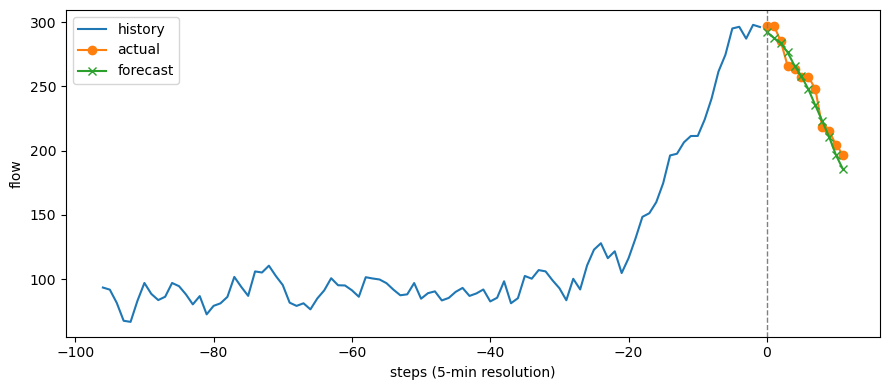

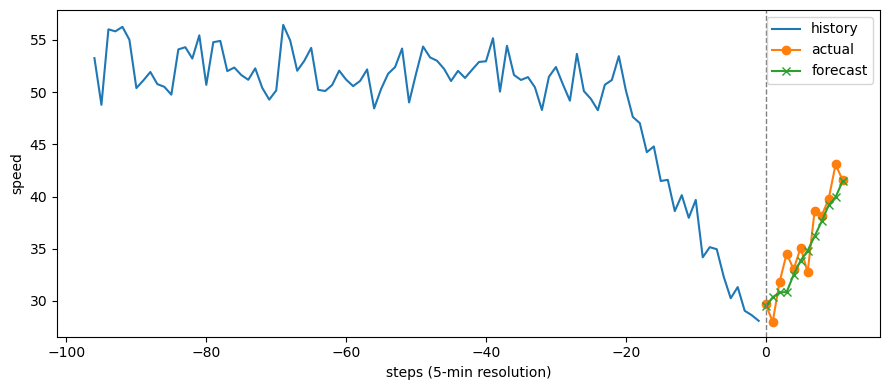

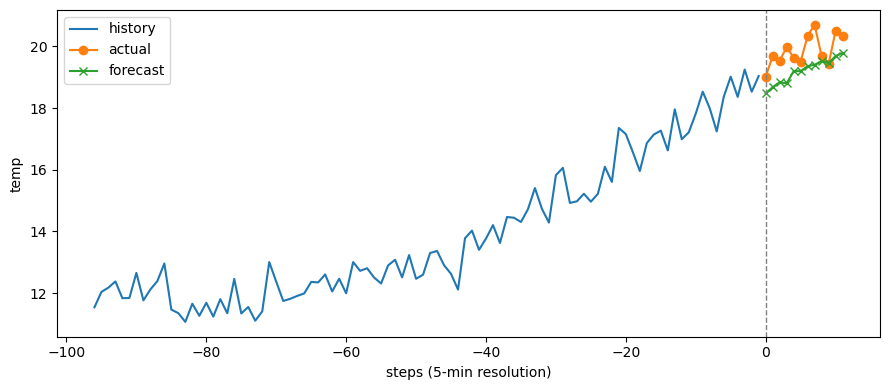

In [9]:
# ---------------------------------------------------------------
# 4. Plot one validation forecast, de-normalized, for "flow"
# ---------------------------------------------------------------
model.eval()
x_sample, y_sample = Xva[0:1], Yva[0:1]
with torch.no_grad():
    pred = model(torch.from_numpy(x_sample).to(device)).cpu().numpy()

for feat in range(3):  # "flow"
    history = x_sample[0, :, feat] * sigma[feat] + mu[feat]
    actual = y_sample[0, :, feat] * sigma[feat] + mu[feat]
    forecast = pred[0, :, feat] * sigma[feat] + mu[feat]

    t_hist, t_fore = np.arange(-T_in, 0), np.arange(0, H)

    plt.figure(figsize=(9, 4))
    plt.plot(t_hist, history, label="history")
    plt.plot(t_fore, actual, label="actual", marker="o")
    plt.plot(t_fore, forecast, label="forecast", marker="x")
    plt.axvline(0, color="gray", linestyle="--", linewidth=1)
    plt.xlabel("steps (5-min resolution)")
    plt.ylabel(feature_names[feat])
    plt.legend()
    plt.tight_layout()
    #plt.savefig("forecast_example.png", dpi=120)
    #print("saved forecast_example.png")